In [1]:
import pandas as pd
import numpy as np
import json

def fix_mvts_index(mvts_df):
    mvts_df.index = pd.to_datetime(mvts_df.index, format="%Y%m%d_%H%M%S")
    return mvts_df


def FlareJSONParser(data):
    none_str = "{\"magnitude\": \"NF\", \"id\": -1, \"NOAA_AR\": -1}"
    if data == 'None':
        j1 = 'None' #json.loads(none_str)['magnitude']
    else:
        data_arr = data.split(';')
#         print('\t', data_arr)
        json_list = []
        max_fl = 'A1.0'
        max_index = np.nan
        for i in range(len(data_arr)):
            json_list.append(json.loads(data_arr[i]) )
            magnitude = json.loads(data_arr[i])['magnitude']
            if max_fl < magnitude:
                max_fl = magnitude
                max_index = i

        j1 = json_list[max_index]['magnitude'] + '@' + str(json_list[max_index]['id'])
    return j1

def read_mvts(file_path, fix_index=True, silent=True):
    # type: (basestring) -> pd.DataFrame
    """Reads and mvts using a given file path, sets the index to DATE__OBS and parses dates"""
    if not silent:
        print(("Reading {0}".format(file_path)))
    mvts_df = pd.read_csv(file_path, index_col='Timestamp', sep='\t', parse_dates=True,
                          converters={'BFLARE_label': FlareJSONParser, 'CFLARE_label': FlareJSONParser,
                                      'MFLARE_label': FlareJSONParser, 'XFLARE_label': FlareJSONParser,
                                      'BFLARE_label_loc': FlareJSONParser, 'CFLARE_label_loc': FlareJSONParser,
                                      'MFLARE_label_loc': FlareJSONParser, 'XFLARE_label_loc': FlareJSONParser}
                          )

    if fix_index:
        return fix_mvts_index(mvts_df)
    else:
        return mvts_df


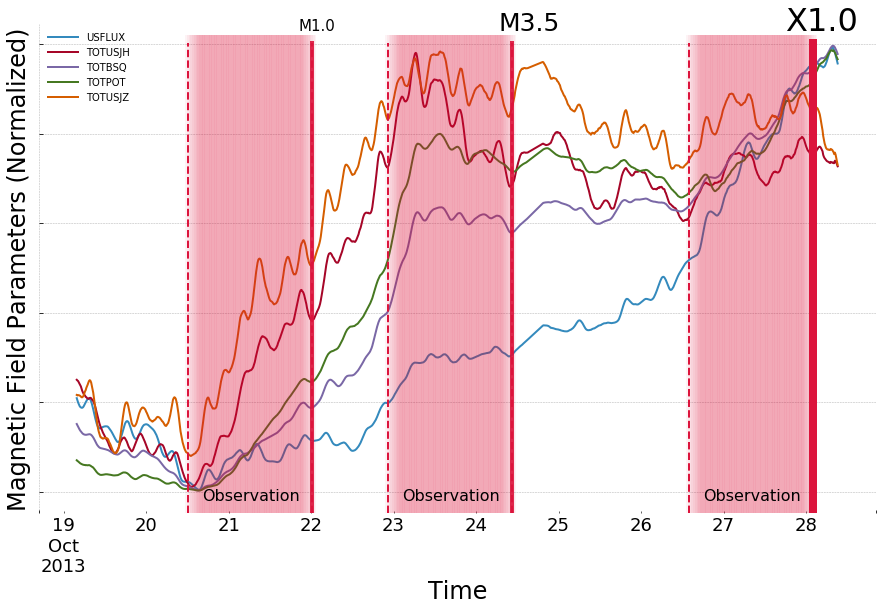

In [5]:
#'../../new-data-folds/fold3/3784.csv'
#'../../new-data-folds/fold3/3730.csv'
#'../../new-data-folds/fold3/3291.csv'
#'../../new-data-folds/fold3/3813.csv'
#'../../new-data-folds/fold3/3344.csv'
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('bmh')


from sklearn import preprocessing

params = {'legend.fontsize': 10,
          'legend.handlelength':3, 'figure.figsize':(12,12), "font.size":12,"axes.titlesize":24,"axes.labelsize":24, 
            "ytick.labelsize": 18, "xtick.labelsize":18}
plt.rcParams.update(params)

columns = ['USFLUX', 'TOTUSJH', 'TOTBSQ', 'TOTPOT', 'TOTUSJZ']
flc = ['XFLARE', 'MFLARE', 'MFLARE_label', 'CFLARE']
ar1 = read_mvts('../../new-data-folds/fold3/3291.csv')
flares = ar1[flc]

xfl = flares['XFLARE'][flares['XFLARE']!= 0]
mfl = flares[['MFLARE', 'MFLARE_label']][flares['MFLARE']!= 0]
cfl = flares['CFLARE'][flares['CFLARE']!= 0]
# print(mfl)

ar1 = ar1[columns]


ar1 = ar1.interpolate(method='linear', axis=0).ffill().bfill()
ar1 = ar1.iloc[200:-200]
# 
min_max_scaler = preprocessing.MinMaxScaler()
z_scaler = preprocessing.StandardScaler()
np_scaled = min_max_scaler.fit_transform(ar1)
ar1 = pd.DataFrame(np_scaled, index=ar1.index, columns = ar1.columns)
ar1 = ar1.rolling(window=11).mean()

# print(ar1.head(1))
ar1 = ar1.iloc[100:]
# print(ar1.head(1))

ax = ar1.plot(figsize=(15, 9))
ax.set_ylabel("Magnetic Field Parameters (Normalized)")
ax.set_xlabel("Time")
ax.set_yticklabels([])


xs = xfl.index.values[0]#[500, 730, 790]
texts = ['X1.0'] * 1# xfl.shape[0]

xs = np.append(xs, mfl.index.values[0])
texts = np.append( texts, ['M1.0'])#*mfl.shape[0] )

xs = np.append(xs, mfl.index.values[7])
texts = np.append( texts, ['M3.5'])#*mfl.shape[0] )

fsize=10
for x, t in zip(xs, texts):
#     ax.annotate(t, xy=(x-np.timedelta64(120, 'm'), 1.03),fontsize=20)
    if t.startswith('M'):
        if t.endswith('0'): fsize = 15
        else: fsize = 25 
        ax.annotate(t, xy=(x-np.timedelta64(240, 'm'), 1.03),fontsize=fsize)
        ax.axvline(x=x, color='crimson',ymin=0.0, alpha=0.9, ymax=0.96, linewidth=4)
        
        ax.axvline(x=x-np.timedelta64(0, 'h'), color='crimson',ymin=0.0, 
                   alpha=0.999, ymax=0.96, linestyle='dashed', linewidth=2)
        ax.axvline(x=x-np.timedelta64(36, 'h'), color='crimson',ymin=0.0, 
                   alpha=0.999, ymax=0.96, linestyle='dashed', linewidth=2)
        
        x = x - np.timedelta64(1, 'h')
        for i in range(68):
            ax.axvline(x=x, color='crimson',ymin=0.0, alpha=0.05, ymax=0.96, linewidth=16)
            x = x - np.timedelta64(30, 'm')
        
        ax.annotate('Observation', xy=(x-np.timedelta64(-180, 'm'), -0.02),fontsize=16)

        
    else:
        ax.annotate(t, xy=(x-np.timedelta64(480, 'm'), 1.03),fontsize=32)

        ax.axvline(x=x, color='crimson',ymin=0.0, ymax=0.96, linewidth=8)
        
        ax.axvline(x=x-np.timedelta64(0, 'h'), color='crimson',ymin=0.0, 
                   alpha=0.999, ymax=0.96, linestyle='dashed', linewidth=2)
        ax.axvline(x=x-np.timedelta64(36, 'h'), color='crimson',ymin=0.0, 
                   alpha=0.999, ymax=0.96, linestyle='dashed', linewidth=2)
        
        x = x - np.timedelta64(1, 'h')
        for i in range(68):
            ax.axvline(x=x, color='crimson',ymin=0.0, alpha=0.05, ymax=0.96, linewidth=16)
            x = x - np.timedelta64(30, 'm')
        ax.annotate('Observation', xy=(x-np.timedelta64(-180, 'm'), -0.02),fontsize=16)
plt.box(False)
ax.legend(fancybox=True, framealpha=0.0)
# ax.set_title('fancy, transparent legends')


mytitle = "flpred"
plt.savefig(mytitle + '.png',  bbox_inches='tight', dpi=600, transparent=True)


In [5]:
plt.style.available

['grayscale',
 'bmh',
 'seaborn-poster',
 'seaborn-deep',
 'seaborn-white',
 '_classic_test',
 'seaborn-ticks',
 'dark_background',
 'seaborn-darkgrid',
 'seaborn-notebook',
 'seaborn-dark',
 'seaborn-muted',
 'fivethirtyeight',
 'ggplot',
 'seaborn-paper',
 'seaborn-talk',
 'seaborn-dark-palette',
 'Solarize_Light2',
 'seaborn-bright',
 'tableau-colorblind10',
 'seaborn',
 'seaborn-colorblind',
 'fast',
 'seaborn-whitegrid',
 'seaborn-pastel',
 'classic']

In [7]:
m10 = ar1.loc[mfl.index.values[0]-np.timedelta64(36, 'h'):mfl.index.values[0]]
m35 = ar1.loc[mfl.index.values[7]-np.timedelta64(36, 'h'):mfl.index.values[7]]
x10 = ar1.loc[xfl.index.values[0]-np.timedelta64(36, 'h'):xfl.index.values[0]]

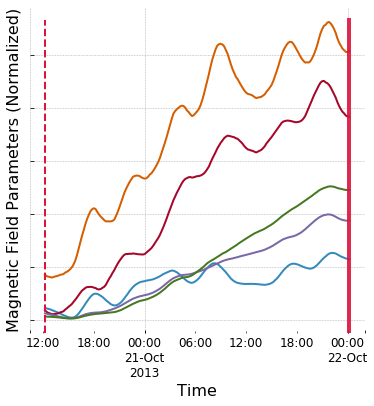

In [10]:
plt.style.use('bmh')
params = {'legend.fontsize': 10,
          'legend.handlelength':3, 'figure.figsize':(5,5), "font.size":8,"axes.titlesize":16,"axes.labelsize":16, 
            "ytick.labelsize": 12, "xtick.labelsize":12}
plt.rcParams.update(params)

ax = m10.plot(figsize=(6, 6))
ax.set_ylabel("Magnetic Field Parameters (Normalized)")
ax.set_xlabel("Time")
ax.set_yticklabels([])

ax.axvline(x=mfl.index.values[0], color='crimson',ymin=0.0, alpha=0.9, ymax=0.96, linewidth=4)

# ax.axvline(x=mfl.index.values[0], color='crimson',ymin=0.0, 
#            alpha=0.999, ymax=0.96, linestyle='dashed', linewidth=2)
ax.axvline(x=mfl.index.values[0]-np.timedelta64(36, 'h'), color='crimson',ymin=0.0, 
           alpha=0.999, ymax=0.96, linestyle='dashed', linewidth=2)
ax.get_legend().remove()
plt.box(False)


mytitle = "m1.0"
# plt.savefig(mytitle + '.pdf',  bbox_inches='tight', dpi=1600)
plt.savefig(mytitle + '.png',  bbox_inches='tight', dpi=600, transparent=True)



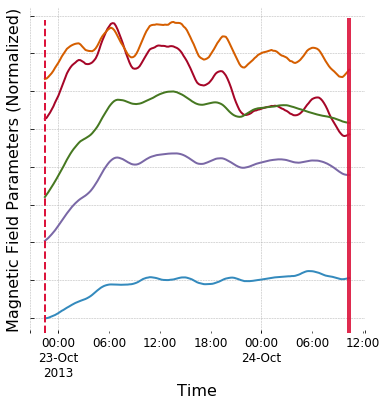

In [11]:
plt.style.use('bmh')
params = {'legend.fontsize': 10,
          'legend.handlelength':3, 'figure.figsize':(5,5), "font.size":8,"axes.titlesize":16,"axes.labelsize":16, 
            "ytick.labelsize": 12, "xtick.labelsize":12}
plt.rcParams.update(params)

ax = m35.plot(figsize=(6, 6))
ax.set_ylabel("Magnetic Field Parameters (Normalized)")
ax.set_xlabel("Time")
ax.set_yticklabels([])

ax.axvline(x=mfl.index.values[7], color='crimson',ymin=0.0, alpha=0.9, ymax=0.96, linewidth=4)

ax.axvline(x=mfl.index.values[7]-np.timedelta64(36, 'h'), color='crimson',ymin=0.0, 
           alpha=0.999, ymax=0.96, linestyle='dashed', linewidth=2)
ax.get_legend().remove()

mytitle = "m3.5"
# plt.savefig(mytitle + '.pdf',  bbox_inches='tight', dpi=1600)

plt.box(False)
plt.savefig(mytitle + '.png',  bbox_inches='tight', dpi=600, transparent=True)



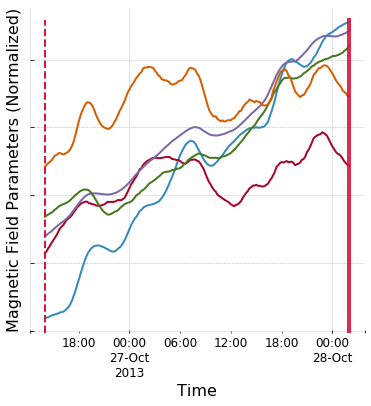

In [12]:
ax = x10.plot(figsize=(6, 6))
ax.set_ylabel("Magnetic Field Parameters (Normalized)")
ax.set_xlabel("Time")
ax.set_yticklabels([])

ax.axvline(x=xfl.index.values[0], color='crimson',ymin=0.0, alpha=0.9, ymax=0.96, linewidth=4)

ax.axvline(x=xfl.index.values[0]-np.timedelta64(36, 'h'), color='crimson',ymin=0.0, 
           alpha=0.999, ymax=0.96, linestyle='dashed', linewidth=2)
ax.get_legend().remove()

mytitle = "x1.0"
# plt.savefig(mytitle + '.pdf',  bbox_inches='tight', dpi=1600)
plt.box(False)
plt.savefig(mytitle + '.png',  bbox_inches='tight', dpi=600, transparent=True)

